# Caricamento Dataset

   feature_0  feature_1  feature_2  ...  feature_13  feature_14  class
0  -0.215992   0.937936   0.241359  ...    1.087886   -0.812614      0
1  -0.741775  -0.684866   1.252277  ...    1.484632   -0.053968      1
2   0.747766   1.231494   0.603151  ...    1.360310   -1.694517      0
3  -0.409211  -0.111560  -0.126949  ...    0.080896   -0.439400      0
4  -0.344474   1.324711  -0.659647  ...    2.871521    0.039601      0

[5 rows x 16 columns]


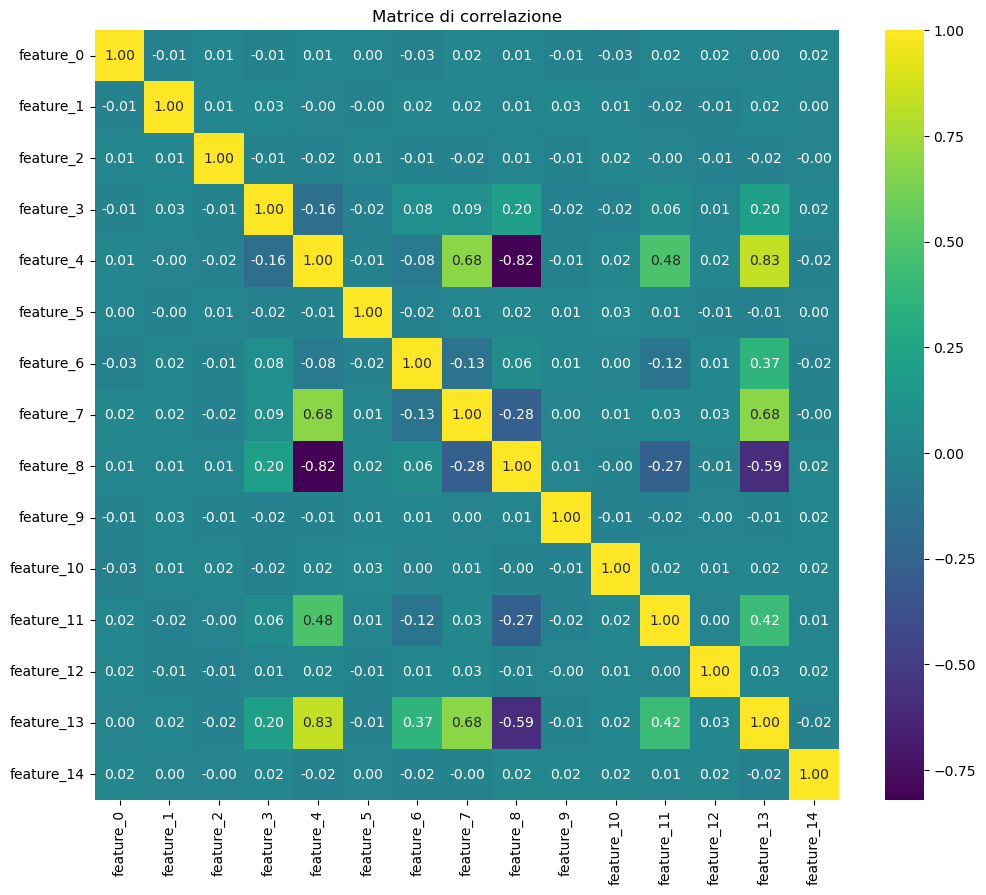

[[np.float64(-0.8208962707252971), 'feature_4', 'feature_8'], [np.float64(0.8346958596073489), 'feature_4', 'feature_13']]
Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_5',
       'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_11',
       'feature_12', 'feature_14', 'feat_combined'],
      dtype='object')


In [ ]:
import pandas as pd
import sklearn

data= pd.read_csv("data.csv")
print(data.head())

X = data.drop(columns="class")
y = data["class"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.05, random_state=42, stratify=y)

# Analisi matrice di correlazione

import matplotlib.pyplot as plt
import seaborn as sns


corr = X_train.corr()
plt.figure(figsize=(12,10))
plt.title("Matrice di correlazione")


sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")
plt.show()

threshold = 0.80
features_correlate = []

for i,col1 in enumerate(corr.columns):
    for col2 in (corr.columns[i+1:]):
        corr_val = corr.loc[col1,col2]
        if abs(corr_val) >threshold:
            features_correlate.append([corr_val,col1,col2])
print(features_correlate)

# Gestione multicollinearita'

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Combinazione lineare sul gruppo, usando dati scalati

corr_group = ["feature_4","feature_8","feature_13"]

X_train_scaled['feat_combined'] = X_train_scaled[corr_group].mean(axis=1)
X_train_scaled = X_train_scaled.drop(columns=corr_group)
X_test_scaled['feat_combined'] = X_test_scaled[corr_group].mean(axis=1)
X_test_scaled = X_test_scaled.drop(columns=corr_group)

print(X_train_scaled.columns)



# Feature Selection tramite FisherScore


In [ ]:
# Qui viene implementato il fisher score a mano

import numpy as np

def fisher_score(X,y):
    # F = (mean - mean)^2 / std + std
    scores = {}
    classi = np.unique(y)
    # Assumendo due classi {0,1}
    X0 = X[ y == classi[0]]
    X1 = X[ y == classi[1]]

    for col in X.columns:
        mu0, mu1 = X0[col].mean(), X1[col].mean()
        var0, var1 = X0[col].var(), X1[col].var()
        scores[col] = (mu0-mu1)**2 / (var0 + var1)

    return pd.Series(scores).sort_values(ascending=False)

"""fisher_scores = fisher_score(X_train_scaled, y_train)
print(fisher_scores) 

top_k = 10
feature_selezionate = fisher_scores.head(top_k).index.tolist()
print(feature_selezionate)

# X_train_final = X_train_scaled[feature_selezionate]
# X_test_final = X_test_scaled[feature_selezionate]
"""

feature_11       1.237243
feature_6        0.262713
feat_combined    0.051127
feature_9        0.003188
feature_1        0.001270
feature_2        0.000925
feature_3        0.000543
feature_5        0.000291
feature_14       0.000136
feature_10       0.000106
feature_12       0.000076
feature_7        0.000071
feature_0        0.000045
dtype: float64
['feature_11', 'feature_6', 'feat_combined', 'feature_9', 'feature_1', 'feature_2', 'feature_3', 'feature_5', 'feature_14', 'feature_10']


# Feature selection con Fisher Score f_classif


In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

selector = SelectKBest(score_func=f_classif, k=10)

# 1. fit SOLO su train
selector.fit(X_train_scaled, y_train)

# 2. ora posso leggere i nomi selezionati
features_selezionate = selector.get_feature_names_out(input_features=X_train_scaled.columns)
print(f"Features selezionate:{features_selezionate}")

# 3. transform su entrambi, senza y
X_train_final = pd.DataFrame(
    selector.transform(X_train_scaled), columns=features_selezionate, index=X_train_scaled.index
)
X_test_final = pd.DataFrame(
    selector.transform(X_test_scaled), columns=features_selezionate, index=X_test_scaled.index
)


Features selezionate:['feature_1' 'feature_2' 'feature_3' 'feature_5' 'feature_6' 'feature_9'
 'feature_10' 'feature_11' 'feature_14' 'feat_combined']


# Classificatore SVM non lineare

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

""""Iperparametri:• C = {1, 1/sqrt(n_samples)} 
                    • kernel=RBF e polinomiale 
                    • grado del kernek polinomiale = {3, 4}  
"""
n_samples = X_train_final.shape[0]

param_grid = {
    'C' : [1, 1/np.sqrt(n_samples)],
    'kernel' : ['rbf','poly'],
    'degree': [3,4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Istanziamo probability=True per poter lavorare con metriche AUC e ROC e Matrice di Confusione
svm = SVC(probability=True, random_state=42)
grid = GridSearchCV(estimator=svm, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=1)
grid.fit(X_train_final,y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_

y_pred_svm = grid.predict(X_test_final)
y_prob_svm = grid.predict_proba(X_test_final)[:,1]

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm) 

print(f"Best model:{best_model}")
print(f"Best params:{best_params}")
print(f"Best score: {best_score:.2f}")

print(f"Accuracy SVM: {acc_svm:.2f}")
print(f"AUC SVM: {auc_svm:.2f}")


Best model:SVC(C=1, probability=True, random_state=42)
Best params:{'C': 1, 'degree': 3, 'kernel': 'rbf'}
Best score: 0.90
Accuracy SVM: 0.92
AUC SVM: 0.96


# Rete neurale

Epoch    1: 100%|██████████| 41/41 [00:00<00:00, 350.18it/s]


Train loss: 0.4057
Validation loss: 0.2767
Test loss: 0.2637 Accuracy:   0.87
Metrics:



Epoch    2: 100%|██████████| 41/41 [00:00<00:00, 428.06it/s]


Train loss: 0.2899
Validation loss: 0.2590
Test loss: 0.2441 Accuracy:   0.93
Metrics:



Epoch    3: 100%|██████████| 41/41 [00:00<00:00, 439.07it/s]


...

Train loss: 0.2491
Validation loss: 0.2000
Test loss: 0.2324 Accuracy:   0.92
Metrics:



Epoch   12: 100%|██████████| 41/41 [00:00<00:00, 514.87it/s]


Train loss: 0.2182
Validation loss: 0.2028
Test loss: 0.2420 Accuracy:   0.90
Metrics:



Epoch   13: 100%|██████████| 41/41 [00:00<00:00, 514.94it/s]


Train loss: 0.2063
Validation loss: 0.1970
Test loss: 0.2192 Accuracy:   0.92
Metrics:



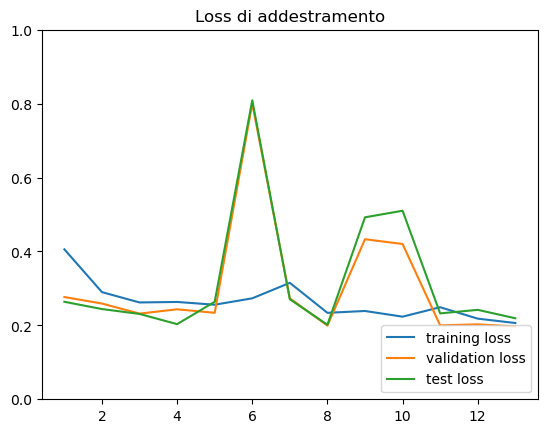

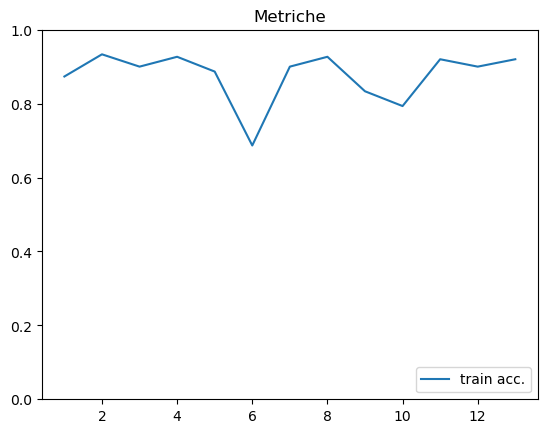

In [15]:
import torch 
import torchnn as tnn
from torch import nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader


# ulteriore split per val set
X_train_nn, X_val_nn,y_train_nn,y_val_nn = train_test_split(X_train_final, y_train, test_size=0.10, random_state=42, stratify=y_train)

class Data(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Dati per la rete neurale
train_data = Data(X_train_nn, y_train_nn)
test_data = Data(X_test_final, y_test)
val_data = Data(X_val_nn,y_val_nn)

# Creazione dataloader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
    
class DataNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),

            
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16,2)
        )
    def forward(self,x):
        return self.layers(x)
    
input_dim = X_train_nn.shape[1]
device = ('cuda' if torch.cuda.is_available() else 'cpu')
model = DataNet(input_dim=input_dim).to(device)

optimizer = optim.RMSprop(model.parameters(),centered=True, weight_decay=1e-4, momentum=0.1, lr=0.01)
scheduler = optim.lr_scheduler.LinearLR(optimizer=optimizer)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.01)
loss_fn = nn.CrossEntropyLoss()

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    device=device,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    val_dataloader=val_loader,
    scheduler=scheduler,
    early_stopping=early_stopping,
    metrics = [],
    average='macro'
)

tnn.displayLosses(train_loss,test_loss,validation_loss)
tnn.displayMetrics(accuracy, test_metrics)
torch.save(model.state_dict(), 'models/best_model.pt')

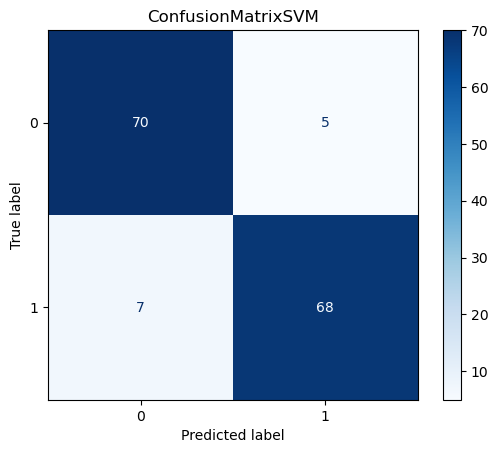

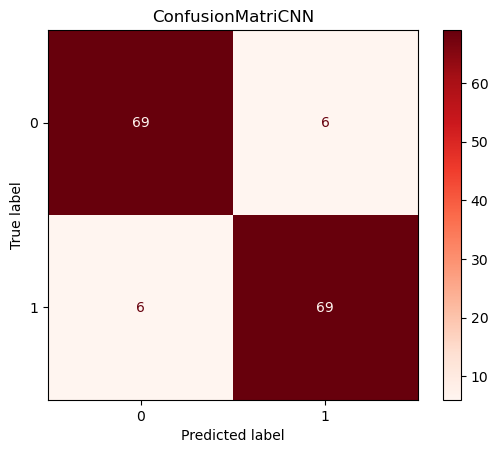

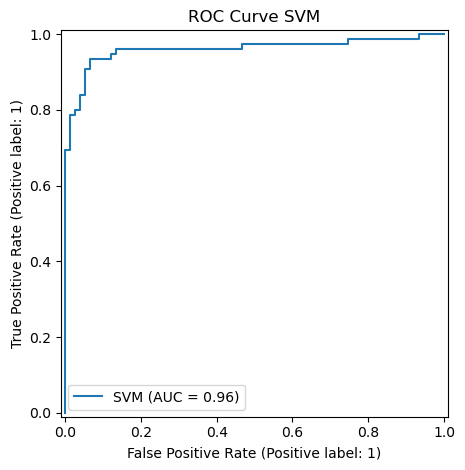

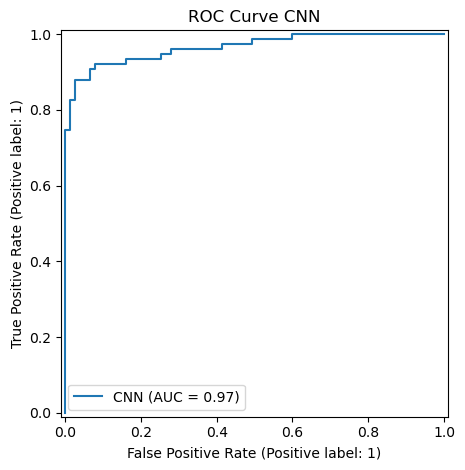

  Modello  Accuracy       AUC
0     SVM      0.92  0.959467
1     CNN      0.92  0.920000


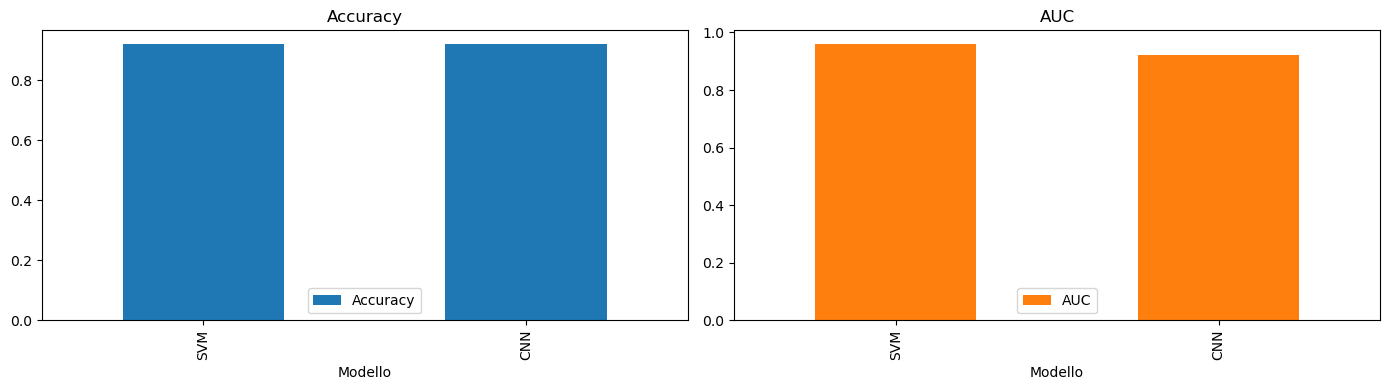

In [17]:
def valuate(model, loss_fn, dataloader):
    model.eval()
    y_true, y_pred, y_prob, losses = [],[],[],[]
    with torch.no_grad():
        for X_batch, y_batch in dataloader:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Previsioni logits
            logits = model(X_batch)
            # Calcoliamo funzione di loss
            loss=loss_fn(logits,y_batch)
            losses.append(loss.item())

            # Funzione softmax per probabilita'
            prob=torch.softmax(logits, dim=1)
            pred=torch.argmax(prob, dim=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob[:,1].cpu().numpy())

        loss_media = np.mean(losses)
        acc_nn = accuracy_score(y_true,y_pred)
        auc_nn = roc_auc_score(y_true,y_pred)
    return loss_media, acc_nn, auc_nn, y_true, y_pred, y_prob

loss_media, acc_nn, auc_nn, y_true, y_pred_nn, y_prob_nn = valuate(model, loss_fn, test_loader)

from sklearn.metrics import confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay

# plot matrice di confusione SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
dis1=ConfusionMatrixDisplay(cm_svm)
dis1.plot(cmap='Blues')
plt.title("ConfusionMatrixSVM")
plt.show()
# plot matrice di confusione Rete neurale
cm_nn=confusion_matrix(y_true, y_pred_nn)
dis2=ConfusionMatrixDisplay(cm_nn)
dis2.plot(cmap='Reds')
plt.title("ConfusionMatriCNN")

RocCurveDisplay.from_predictions(y_test,y_prob_svm, name='SVM')
plt.title("ROC Curve SVM")
plt.tight_layout()
plt.legend()
plt.show()

RocCurveDisplay.from_predictions(y_true,y_prob_nn, name='CNN')
plt.title("ROC Curve CNN")
plt.tight_layout()
plt.legend()
plt.show()

res=pd.DataFrame({
    'Modello' :['SVM', 'CNN'],
    'Accuracy' : [acc_svm, acc_nn],
    'AUC' : [auc_svm, auc_nn]
    })

print(res)
res.plot(kind='bar', sharex=True, layout=(1,2) , figsize=(14,4) , x='Modello', y=['Accuracy', 'AUC'], subplots=True)
plt.tight_layout()
plt.legend()
plt.show()


